In [19]:
import numpy as np
import pandas as pd

In [20]:
class MarketSimulator:
    def __init__(self, beta_matrix, competitor_designs, market_size):
        self.betas          = beta_matrix
        self.comp_designs   = competitor_designs
        self.market_size    = market_size
        self.comp_utilities = np.dot(self.betas, self.comp_designs.T)

    def evaluate_product(self, our_design, our_price, our_cost, price_betas):
        feature_utility = np.dot(self.betas, our_design.T)
        our_utility     = feature_utility + price_betas * our_price
        all_utilities   = np.hstack((self.comp_utilities, our_utility))
        exp_utilities   = np.exp(all_utilities)
        probabilities   = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)
        market_share    = np.mean(probabilities[:, -1])
        profit          = market_share * self.market_size * (our_price - our_cost)
        return market_share, profit

    def evaluate_portfolio(self, designs_matrix, prices_array, costs_array, price_betas):
        price_utilities = price_betas * prices_array                          # (R, N)
        feature_utils   = np.dot(self.betas, designs_matrix.T)               # (R, N)
        our_utilities   = feature_utils + price_utilities                     # (R, N)
        all_utilities   = np.hstack((self.comp_utilities, our_utilities))     # (R, C+N)
        exp_utilities   = np.exp(all_utilities)
        probabilities   = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)
        our_probs       = probabilities[:, -designs_matrix.shape[0]:]         # (R, N)
        shares          = np.mean(our_probs, axis=0)                          # (N,)
        profits         = shares * self.market_size * (prices_array - costs_array)
        return shares, np.sum(shares), np.sum(profits)

    def compute_commonality(self, candidate_indices, candidate_designs, attributes):
        """
        Computes the Commonality Index (0-1) for a set of selected candidates.
        For each attribute, finds the most popular level chosen across the portfolio
        and scores it as a fraction of total products. Averages across all attributes.
        """
        # Decode each selected candidate back to one level-choice per attribute
        selected = candidate_designs[candidate_indices]   # (num_products, total_levels)
        agreement_rates = []
        offset = 0
        for _, num_levels in attributes:
            level_slice  = selected[:, offset : offset + num_levels]  # (N, L)
            level_choices = np.argmax(level_slice, axis=1)             # (N,) — which level each product picked
            counts        = np.bincount(level_choices, minlength=num_levels)
            agreement_rates.append(counts.max() / len(candidate_indices))
            offset += num_levels
        return np.mean(agreement_rates)

In [33]:
i# --- Define Attribute Structure ---
attributes = [
    ("A1", 9),
    ("A2", 7),
    ("A3", 4),
    ("A4", 6),
    ("A5", 8),
    ("A6", 8),
    ("A7", 4),
    ("A8", 8),
]

# --- Define Competitors ---
competitors = [
    {"name": "Competitor A", "price": 199.00, "levels": [2,  3,  1,  2,  4,  0,  1,  3]},
    {"name": "Competitor B", "price": 299.00, "levels": [5,  5,  2,  4,  6,  3,  2,  5]},
    {"name": "Competitor C", "price": 399.00, "levels": [7,  6,  3,  5,  7,  6,  3,  6]},
]

# --- Define YOUR candidate products ---
our_products = [
    {"name": "Product 1", "levels": [1,  1,  0,  1,  2,  1,  0,  2]},
    {"name": "Product 2", "levels": [3,  2,  1,  2,  3,  2,  1,  3]},
    {"name": "Product 3", "levels": [4,  3,  2,  3,  4,  4,  2,  4]},
    {"name": "Product 4", "levels": [6,  4,  1,  4,  5,  5,  1,  5]},
    {"name": "Product 5", "levels": [8,  6,  3,  5,  7,  7,  3,  7]},
    {"name": "Product 6", "levels": [2,  0,  0,  0,  1,  0,  0,  1]},
    {"name": "Product 7", "levels": [5,  5,  2,  3,  6,  3,  2,  6]},
    {"name": "Product 8", "levels": [7,  2,  3,  5,  3,  6,  1,  4]},
]

# --- Number of products in final portfolio ---
NUM_PRODUCTS = int(input("Enter the number of products to be used in the final portfolio: "))

# --- Automatically derive everything else — DO NOT TOUCH ---
num_levels    = [a[1] for a in attributes]
total_levels  = sum(num_levels)
start_indices = [sum(num_levels[:i]) for i in range(len(num_levels))]

# Validate products and competitors
for prod in our_products:
    assert len(prod["levels"]) == len(attributes), \
        f"{prod['name']} has {len(prod['levels'])} level values but there are {len(attributes)} attributes"
for comp in competitors:
    assert len(comp["levels"]) == len(attributes), \
        f"{comp['name']} has {len(comp['levels'])} level values but there are {len(attributes)} attributes"
print("Validation passed — all products and competitors have the correct number of levels")

# Build competitor one-hot matrix
competitor_matrix = np.zeros((len(competitors), total_levels), dtype=int)
for row, comp in enumerate(competitors):
    for attr_i, level_choice in enumerate(comp["levels"]):
        competitor_matrix[row, start_indices[attr_i] + level_choice] = 1
comp_prices = np.array([[c["price"]] for c in competitors])

# Build candidate one-hot matrix
candidate_designs = np.zeros((len(our_products), total_levels), dtype=int)
for row, prod in enumerate(our_products):
    for attr_i, level_choice in enumerate(prod["levels"]):
        candidate_designs[row, start_indices[attr_i] + level_choice] = 1

print(f"Attributes     : {[a[0] for a in attributes]}")
print(f"Levels per attr: {num_levels}")
print(f"Competitors    : {len(competitors)}")
print(f"Candidates     : {len(our_products)}  ->  picking best {NUM_PRODUCTS}")
print(f"\nCandidate designs matrix:\n{candidate_designs}")

# --- Load Beta Values from CSV ---
file_path = r"E:\NCSU Spring '26\Python\beta_utilities.csv"  # enter path for bet value csv

df = pd.read_csv(file_path)
df = df.drop(columns=["Respondent", "NONE"])

assert df.shape[1] == total_levels, (
    f"Mismatch! Code expects {total_levels} columns but file has {df.shape[1]}. "
    f"Check that your attributes list matches the CSV structure."
)

beta_matrix     = df.values
num_respondents = beta_matrix.shape[0]
print(f"\nLoaded {num_respondents} respondents from CSV.")

# --- Price Sensitivities (still simulated for now) ---
price_betas = np.random.normal(loc=-0.01, scale=0.002, size=(num_respondents, 1))

# --- User Inputs ---
market_size = 500000
our_cost = 50.0
price_min = 99
price_max = 499

if price_min <= our_cost:
    price_min = our_cost
    print(f"Warning: Minimum price was below cost. Adjusted to ${price_min:.2f}")

# --- Instantiate simulator ---
simulator = MarketSimulator(beta_matrix, competitor_matrix, market_size)
simulator.comp_utilities += np.dot(price_betas, comp_prices.T)

Enter the number of products to be used in the final portfolio:  6


Validation passed — all products and competitors have the correct number of levels
Attributes     : ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']
Levels per attr: [9, 7, 4, 6, 8, 8, 4, 8]
Competitors    : 3
Candidates     : 8  ->  picking best 6

Candidate designs matrix:
[[0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
  0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0
  1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0
  0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0
  0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0
  0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0
  0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 

In [34]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

class PortfolioOptimizer(ElementwiseProblem):

    def __init__(self, sim, price_betas, candidate_designs, our_products,
                 num_products, our_cost, price_min, price_max, attributes):
        self.sim               = sim
        self.price_betas       = price_betas
        self.candidate_designs = candidate_designs
        self.num_products      = num_products
        self.our_cost          = our_cost
        self.num_candidates    = len(our_products)
        self.attributes        = attributes

        lower_one = np.array([0,                        price_min])
        upper_one = np.array([self.num_candidates - 1,  price_max])
        xl = np.tile(lower_one, num_products)
        xu = np.tile(upper_one, num_products)

        super().__init__(n_var=num_products * 2, n_obj=3, xl=xl, xu=xu)

    def _evaluate(self, x, out, *args, **kwargs):

        # --- Duplicate guard: penalise any portfolio with repeated candidates ---
        candidate_indices = [int(round(x[i * 2])) for i in range(self.num_products)]
        if len(candidate_indices) != len(set(candidate_indices)):
            out["F"] = [0, 0, 0]
            return

        designs_list = []
        prices_list  = []

        for i in range(self.num_products):
            offset        = i * 2
            candidate_idx = int(round(x[offset]))
            price         = x[offset + 1]
            designs_list.append(self.candidate_designs[candidate_idx])
            prices_list.append(price)

        designs_matrix = np.array(designs_list)
        prices_array   = np.array(prices_list)
        costs_array    = np.full(self.num_products, self.our_cost)

        _, portfolio_share, portfolio_profit = self.sim.evaluate_portfolio(
            designs_matrix, prices_array, costs_array, self.price_betas
        )

        # --- Commonality Index — computed directly over the selected designs ---
        agreement_rates = []
        offset = 0
        for _, lvl in self.attributes:
            col_slice = designs_matrix[:, offset : offset + lvl]   # (num_products, lvl)
            choices   = np.argmax(col_slice, axis=1)               # which level each product picked
            counts    = np.bincount(choices, minlength=lvl)
            agreement_rates.append(counts.max() / self.num_products)
            offset += lvl
        commonality = np.mean(agreement_rates)

        out["F"] = [-portfolio_share, -portfolio_profit, -commonality]

In [35]:
res = minimize(
    PortfolioOptimizer(simulator, price_betas, candidate_designs, our_products,
                       NUM_PRODUCTS, our_cost, price_min, price_max, attributes),
    NSGA2(pop_size=200),
    ('n_gen', 200),
    verbose=False
)

portfolio_shares      = -res.F[:, 0] * 100
portfolio_profits     = -res.F[:, 1]
portfolio_commonality = -res.F[:, 2] * 100

# --- Decode helper ---
def decode_solution(x_sol):
    products = []
    for i in range(NUM_PRODUCTS):
        offset = i * 2
        idx   = int(round(x_sol[offset]))
        price = x_sol[offset + 1]
        products.append({"name": our_products[idx]["name"],
                         "levels": our_products[idx]["levels"],
                         "price": price})
    return products

def print_solution(label, x_sol, share, profit, commonality):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"  Portfolio share: {share:.2f}%  |  Profit: ${profit:,.2f}  |  Commonality: {commonality:.2f}%")
    print(f"  {'─'*55}")
    print(f"  {'Slot':<6} {'Product':<14} {'Levels':<20} {'Price':>8}")
    for i, p in enumerate(decode_solution(x_sol)):
        print(f"  P{i+1:<5} {p['name']:<14} {str(p['levels']):<20} ${p['price']:>6.2f}")

# --- Pareto summary ---
print(f"Found {len(res.F)} Pareto-optimal portfolios\n" + "-"*45)
print(f"{'Portfolio Share':>18}  {'Portfolio Profit':>18}  {'Commonality':>13}")
print("-"*55)
for share, profit, commonality in zip(portfolio_shares, portfolio_profits, portfolio_commonality):
    print(f"{share:>17.2f}%  ${profit:>17,.2f}  {commonality:>12.2f}%")

# --- Print the three extremes ---
best_share_idx       = np.argmax(portfolio_shares)
best_profit_idx      = np.argmax(portfolio_profits)
best_commonality_idx = np.argmax(portfolio_commonality)

print_solution("MAX PORTFOLIO SHARE",
               res.X[best_share_idx],
               portfolio_shares[best_share_idx],
               portfolio_profits[best_share_idx],
               portfolio_commonality[best_share_idx])

print_solution("MAX PORTFOLIO PROFIT",
               res.X[best_profit_idx],
               portfolio_shares[best_profit_idx],
               portfolio_profits[best_profit_idx],
               portfolio_commonality[best_profit_idx])

print_solution("MAX COMMONALITY",
               res.X[best_commonality_idx],
               portfolio_shares[best_commonality_idx],
               portfolio_profits[best_commonality_idx],
               portfolio_commonality[best_commonality_idx])

Found 200 Pareto-optimal portfolios
---------------------------------------------
   Portfolio Share    Portfolio Profit    Commonality
-------------------------------------------------------
            55.10%  $   118,557,449.54         31.25%
            83.20%  $    20,512,794.26         22.92%
            81.58%  $    41,576,769.14         22.92%
            55.99%  $   119,569,809.57         22.92%
            82.90%  $    20,466,721.96         31.25%
            63.45%  $   112,325,721.90         31.25%
            77.43%  $    69,287,478.78         22.92%
            71.43%  $    93,315,940.10         31.25%
            78.69%  $    61,351,763.48         31.25%
            66.19%  $   107,560,915.27         31.25%
            65.73%  $   108,476,502.67         31.25%
            61.39%  $   116,018,461.11         22.92%
            81.99%  $    32,274,082.37         31.25%
            78.41%  $    63,525,580.21         31.25%
            60.07%  $   116,338,725.69         31.25

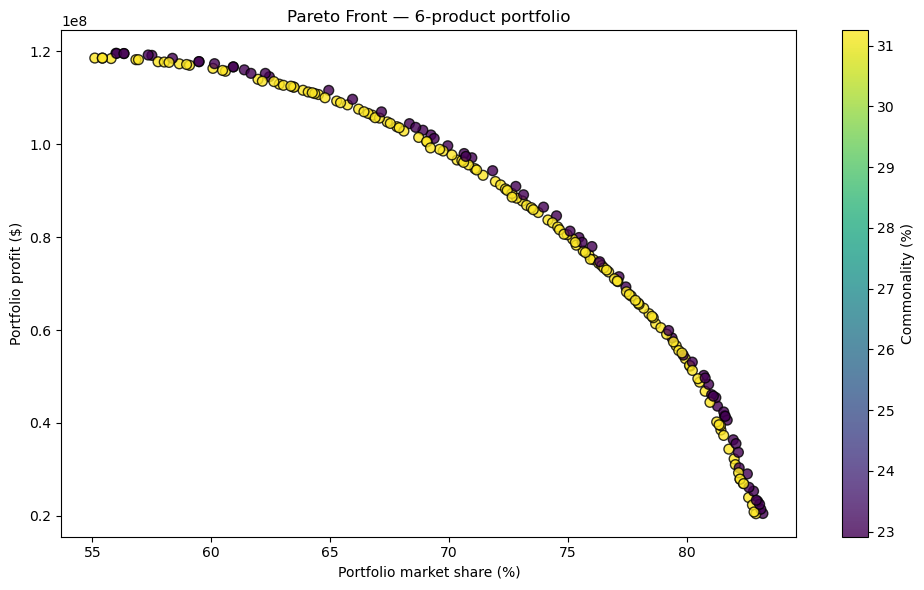

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    portfolio_shares, portfolio_profits,
    c=portfolio_commonality, cmap='viridis', s=50, alpha=0.8, edgecolors='black'
)
plt.colorbar(sc, ax=ax, label="Commonality (%)")

ax.set_xlabel("Portfolio market share (%)")
ax.set_ylabel("Portfolio profit ($)")
ax.set_title(f"Pareto Front — {NUM_PRODUCTS}-product portfolio")

plt.tight_layout()
plt.show()